# Statistical analysis of `gender_given` prompt cases

I want to be determine if there a behavioural difference across models when gender is specified to be one binary value or another. For this I am planning a logistic regression anaylsis to see if diversity and entropy metrics are informative of gender/have significant predictive power over the label.

## Load data

In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent
results_dir = root_dir / "data" / "olmo7b_results" / "v2"
sys.path.insert(0, str(root_dir))
from utils import load_json_data, save_dataframes

KEYWORD = "given"   # can otherwise be "assumed"
PREFIX = "combined"  # can be None

loaded_dfs = load_json_data(results_dir, 
                            file_name_keyword=KEYWORD, 
                            prefix=PREFIX)
print(f"Loaded the following {KEYWORD} dfs:")
for k in loaded_dfs.keys():
    print(k)

WARNING UTILS: model_utils could not be loaded; ensure that torch is installed if you intend to use it.
Loaded the following given dfs:
combined_metrics_olmo7b_given


In [2]:
list(loaded_dfs.values())[0].head()

,model_key,profile_id,temperature,occupation_category,attended_university,response_number,mean_entropy,mean_entropy_nucleus,gender,self_bleu,semantic_div,perplexity
0,base,1,0.2,officers in regular armed forces,no,1,0.206833,0.153161,male,0.34691,0.317608,11.525167
1,base,1,0.2,officers in regular armed forces,no,2,0.191472,0.143714,male,0.34691,0.317608,11.525167
2,base,1,0.2,officers in regular armed forces,no,3,0.154052,0.110273,male,0.34691,0.317608,11.525167
3,base,1,0.2,officers in regular armed forces,no,4,0.150479,0.100602,male,0.34691,0.317608,11.525167
4,base,1,0.2,officers in regular armed forces,no,5,0.136403,0.095563,male,0.34691,0.317608,11.525167


In [3]:
import pandas as pd
combined_df = None
if PREFIX == "combined":
    combined_df = list(loaded_dfs.values())[0]
    print("Combined df columns:", combined_df.columns)
    print("Combined df shape:", combined_df.shape)
elif len(loaded_dfs) > 1:
    # combine all dfs into one (vertically)
    all_dfs = list(loaded_dfs.values())
    combined_df = pd.concat(all_dfs).reset_index(drop=True)
    print("Combined df columns:", combined_df.columns)
    assert combined_df.shape[0] == sum(df.shape[0] for df in all_dfs), "Row count mismatch after concatenation"
    print("Combined df shape:", combined_df.shape)
    save_dataframes({f"combined_metrics_olmo7b_{KEYWORD}": combined_df}, results_dir)

# Print total entries per model
print(f"Entries per model:\n{combined_df['model_key'].value_counts()}")

Combined df columns: Index(['model_key', 'profile_id', 'temperature', 'occupation_category',
       'attended_university', 'response_number', 'mean_entropy',
       'mean_entropy_nucleus', 'gender', 'self_bleu', 'semantic_div',
       'perplexity'],
      dtype='str')
Combined df shape: (17600, 12)
Entries per model:
model_key
base    4400
dpo     4400
rlvr    4400
sft     4400
Name: count, dtype: int64


In [4]:
# number of unique entropy values
print(f"Unique mean_entropy values: {combined_df['mean_entropy'].nunique()}")
print(f"Unique mean_entropy_nucleus values: {combined_df['mean_entropy_nucleus'].nunique()}")
print(f"Unique semantic_div values: {combined_df['semantic_div'].nunique()}")
print(f"Unique self_bleu values: {combined_df['self_bleu'].nunique()}")
print(f"Unique perplexity values: {combined_df['perplexity'].nunique()}")

Unique mean_entropy values: 17599
Unique mean_entropy_nucleus values: 17045
Unique semantic_div values: 3520
Unique self_bleu values: 3520
Unique perplexity values: 3520


## Logistic Regression setup

Columns to encode = `[model_key, occupation_category, attended_university, gender]` and all except `occupation` can be *one-hot encoded*.
And the outcome variable would be a binary male/female (`gender`) variable. I will drop `response_number` and `profile_id` for the regression model.

Also need to group the entries by `profile_id` and average the entropy metrics (since the rest are already computed over groups).

In [ ]:
# Encode gender to 0/1 for regression
combined_df['gender_code'] = combined_df['gender'].map({'female': 0, 'male': 1})

In [ ]:
# Drop columns that are not necessary for regression
cols_to_drop = ['response_number', 'attended_university', 'occupation_category', 'gender', 'mean_entropy']
combined_df = combined_df.drop(columns=cols_to_drop, errors='ignore')
print("Columns after dropping unnecessary ones:", combined_df.columns)
# keeping temperature:controlling for the fact that higher temps produce higher entropy, is there still a gender signal in entropy?

In [ ]:
# Group by profile_id and average the entropy metrics
entropy_cols = ['mean_entropy_nucleus']#, 'mean_entropy_nucleus']
combined_df[entropy_cols] = combined_df.groupby('profile_id')[entropy_cols].transform('mean')
reg_df = combined_df.drop_duplicates(subset=['profile_id', 'model_key', 'temperature'])
print("Entropy metrics averaged by profile_id")
reg_df.head(10)

### Run logreg for each model subset

I will break down the df into 4 subsets: for each model, and run a regression model for each.

In [ ]:
# Initialise scaler for all the continuous metric cols for regression
continuous_cols = ['mean_entropy_nucleus', 'semantic_div', 'self_bleu', 'perplexity']#, 'mean_entropy_nucleus']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scaling globally to keep information about the relative differences across models
reg_df[continuous_cols] = scaler.fit_transform(reg_df[continuous_cols])
reg_df.head(10)

Now I will run 4 regression models.

In [ ]:
import statsmodels.formula.api as smf

formula = """
    gender_code ~ mean_entropy_nucleus  
               + self_bleu + semantic_div + perplexity
               + temperature  
"""

results = {}
for model_name, group in reg_df.groupby('model_key'):
    fit = smf.logit(formula, data=group).fit()
    results[model_name] = fit

# Then compare coefficients across models
for model_name, fit in results.items():
    print(f"\n=== {model_name} ===")
    print(fit.summary())

## Linear Regression

I want to run multiple linear regression models on each metric to check if gender and post-training stage have effects (main and interactive) on each metric.

In [5]:
combined_df.columns, len(combined_df)

(Index(['model_key', 'profile_id', 'temperature', 'occupation_category',
        'attended_university', 'response_number', 'mean_entropy',
        'mean_entropy_nucleus', 'gender', 'self_bleu', 'semantic_div',
        'perplexity'],
       dtype='str'),
 17600)

### Preprocess df

* Group prompts per model and temperature
* as a result, average the metrics

This way I will be treating each "group" of generations as the basic unit: "average {metric} for each `prompt (occ, gender, edu) x model x temp`. 

In [6]:
# Run preprocessing steps:
# Group by profile_id and average the entropy metrics
entropy_cols = ['mean_entropy_nucleus', 'mean_entropy']
combined_df[entropy_cols] = combined_df.groupby(['profile_id', 'model_key', 'temperature'])[entropy_cols].transform('mean')
# Drop duplicate rows
linreg_df = combined_df.drop_duplicates(subset=['profile_id', 'model_key', 'temperature'])

print(f"Entropy metrics averaged by profile_id, total entries remaining: {linreg_df.shape[0]}")
linreg_df.head(10)

Entropy metrics averaged by profile_id, total entries remaining: 3520


,model_key,profile_id,temperature,occupation_category,attended_university,response_number,mean_entropy,mean_entropy_nucleus,gender,self_bleu,semantic_div,perplexity
0,base,1,0.2,officers in regular armed forces,no,1,0.167848,0.120663,male,0.346910,0.317608,11.525167
5,base,2,0.2,non-commissioned officers in regular armed forces,no,1,0.145826,0.098576,male,0.549618,0.113976,13.220261
10,base,3,0.2,other ranks in regular armed forces,no,1,0.149820,0.100391,male,0.493192,0.246709,10.853041
15,base,4,0.2,"managing directors, board members, senior admi...",no,1,0.155092,0.109949,male,0.455229,0.341614,11.104241
20,base,5,0.2,managers in commercial fields,no,1,0.149151,0.102469,male,0.393514,0.345137,12.437788
25,base,6,0.2,managers in production and specialized services,no,1,0.166602,0.115536,male,0.332367,0.370686,13.732744
30,base,7,0.2,"managers in hotels, restaurants, trade, and ot...",no,1,0.161276,0.112161,male,0.455236,0.263575,14.642786
35,base,8,0.2,"scientists, mathematicians, and engineers",no,1,0.153037,0.103101,male,0.469745,0.307749,12.405449
40,base,9,0.2,specialists in health professions,no,1,0.149642,0.102100,male,0.444786,0.300871,12.549057
45,base,10,0.2,teachers,no,1,0.140672,0.099365,male,0.427374,0.238464,12.521621


Define functions for processing `df` for regression, and function for running a regression analysis.

In [7]:
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler

def prepare_df_for_regression(df, transform_cols, scaling_cols, transform=None):
    # Create binary indicator columns
    df['is_female'] = (df['gender'] == 'female').astype(int)

    # One-hot encode model type with base as the reference
    # (just don't create an is_base column — it's the implicit reference)
    df['is_sft'] = (df['model_key'] == 'sft').astype(int)
    df['is_dpo'] = (df['model_key'] == 'dpo').astype(int)
    df['is_rlvr'] = (df['model_key'] == 'rlvr').astype(int)

    if transform: # is not None or False
    # Apply the specified transformation
        if transform == 'sqrt':
            print("=== Applying sqrt transform ===")
            for col in transform_cols:
                df[col] = np.sqrt(df[col])
        elif transform == 'log':
            print("=== Applying log transform ===")
            for col in transform_cols:
                df[col] = np.log(df[col])
        else: # I will pass a default value of True to apply boxcox
            print("=== Applying boxcox transform ===")
            for col in transform_cols:
                transformed, optimal_lambda = stats.boxcox(df[col])
                print(f"[{col}] optimal lambda: {optimal_lambda:.3f}")
                print(f"[{col}] skew after transform: {stats.skew(transformed):.3f}")
                print(f"[{col}] kurtosis after transform: {stats.kurtosis(transformed, fisher=False):.3f}")
                df[col] = transformed
    
    # Scale all continuous columns
    scaler = StandardScaler()
    df[scaling_cols] = scaler.fit_transform(df[scaling_cols])
    return df

import statsmodels.formula.api as smf
# Run separate OLS for each outcome metric
# in this setting, I am dealing only with "interaction" behaviour using `:`
# instead of mixed-effects which would use `*`
def linear_regression_analysis(linreg_df, regression_metrics):
    results = {}
    for metric in regression_metrics:
        formula = f"""
            {metric} ~ is_female + is_sft + is_dpo + is_rlvr
                        + is_female:is_sft + is_female:is_dpo + is_female:is_rlvr
                        + temperature
        """

        fit = smf.ols(formula, data=linreg_df).fit()
        results[metric] = fit

    return results

In [8]:
# Define columns to prepare for linear regression analysis
continuous_cols = [                 # for applying StandardScaler
    'mean_entropy_nucleus', 
    'semantic_div', 
    'self_bleu', 
    'perplexity', 
    'mean_entropy', 
    'temperature'
]
regression_metrics = [              # outcome vars for regression analysis
    'mean_entropy',
    'mean_entropy_nucleus',
    'semantic_div',
    'self_bleu',
    'perplexity'
]
transform_cols = [                 # for applying transformations to correct skew
    'mean_entropy',
    'mean_entropy_nucleus',
    'perplexity',
    'self_bleu'
]

linreg_df = prepare_df_for_regression(linreg_df, transform_cols, continuous_cols, transform='boxcox')
results = linear_regression_analysis(linreg_df, regression_metrics)

=== Applying boxcox transform ===
[mean_entropy] optimal lambda: -0.035
[mean_entropy] skew after transform: 0.012
[mean_entropy] kurtosis after transform: 2.092
[mean_entropy_nucleus] optimal lambda: -0.077
[mean_entropy_nucleus] skew after transform: 0.026
[mean_entropy_nucleus] kurtosis after transform: 2.135
[perplexity] optimal lambda: -0.431
[perplexity] skew after transform: 0.088
[perplexity] kurtosis after transform: 2.797
[self_bleu] optimal lambda: 0.435
[self_bleu] skew after transform: -0.127
[self_bleu] kurtosis after transform: 2.174


In [9]:
# Sanity check: 50% entries should be female, and 25% should be each model
total_entries = len(linreg_df)
print(f"Proportion of entries with is_female: {sum(linreg_df['is_female'].to_list()) / total_entries}")
print(f"Proportion of entries with is_sft: {sum(linreg_df['is_sft'].to_list()) / total_entries}")
print(f"Proportion of entries with is_dpo: {sum(linreg_df['is_dpo'].to_list()) / total_entries}")
print(f"Proportion of entries with is_rlvr: {sum(linreg_df['is_rlvr'].to_list()) / total_entries}")

Proportion of entries with is_female: 0.5
Proportion of entries with is_sft: 0.25
Proportion of entries with is_dpo: 0.25
Proportion of entries with is_rlvr: 0.25


In [10]:
# Then compare coefficients across models
for model_name, fit in results.items():
    print(f"\n=== {model_name} ===")
    print(fit.summary())


=== mean_entropy ===
                            OLS Regression Results                            
Dep. Variable:           mean_entropy   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                 1.300e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:37:13   Log-Likelihood:                 1027.6
No. Observations:                3520   AIC:                            -2037.
Df Residuals:                    3511   BIC:                            -1982.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept       

### Visualising some metrics

From the OLS regression I think perplexity is highly skewed and might benefit from a log-transform. But I would like to check.

Plotting mean_entropy distribution for model: base, number of entries: 880, unique values: 880
Plotting mean_entropy distribution for model: dpo, number of entries: 880, unique values: 880
Plotting mean_entropy distribution for model: rlvr, number of entries: 880, unique values: 880
Plotting mean_entropy distribution for model: sft, number of entries: 880, unique values: 880


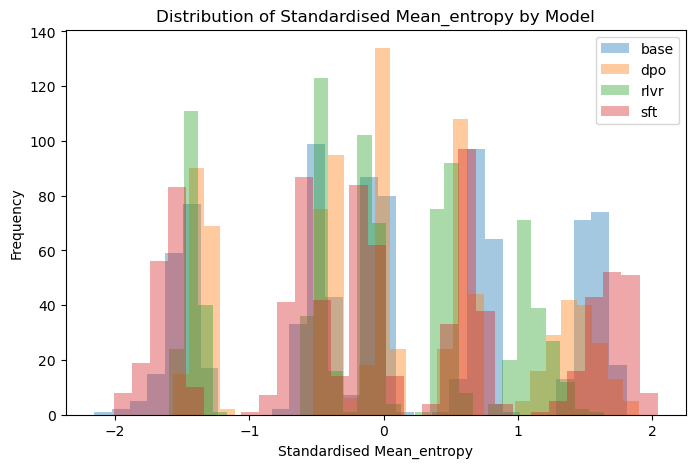

Plotting mean_entropy_nucleus distribution for model: base, number of entries: 880, unique values: 880
Plotting mean_entropy_nucleus distribution for model: dpo, number of entries: 880, unique values: 880
Plotting mean_entropy_nucleus distribution for model: rlvr, number of entries: 880, unique values: 880
Plotting mean_entropy_nucleus distribution for model: sft, number of entries: 880, unique values: 880


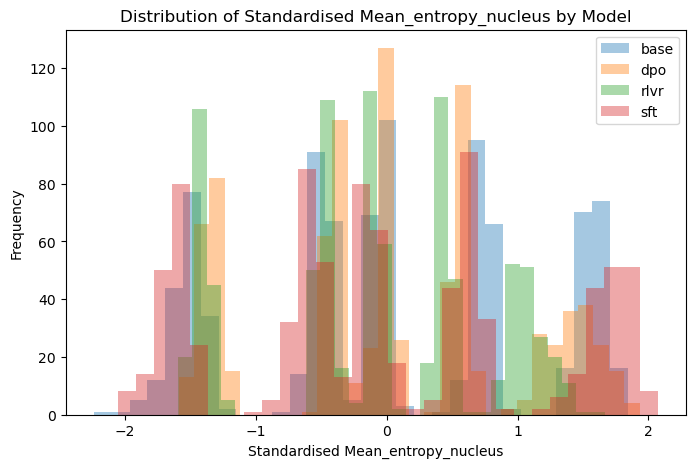

Plotting semantic_div distribution for model: base, number of entries: 880, unique values: 880
Plotting semantic_div distribution for model: dpo, number of entries: 880, unique values: 880
Plotting semantic_div distribution for model: rlvr, number of entries: 880, unique values: 880
Plotting semantic_div distribution for model: sft, number of entries: 880, unique values: 880


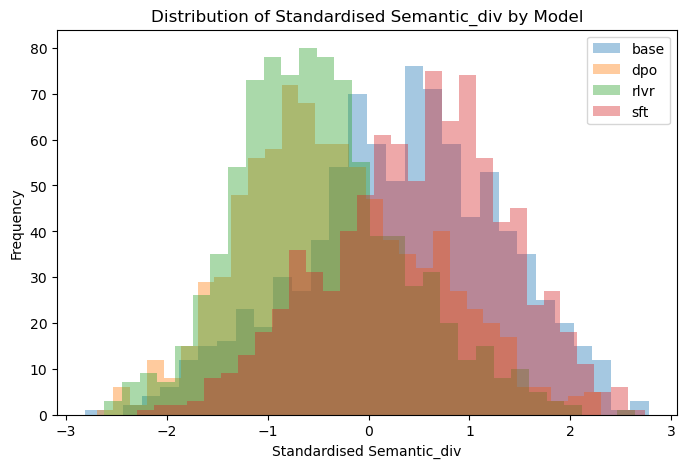

Plotting self_bleu distribution for model: base, number of entries: 880, unique values: 880
Plotting self_bleu distribution for model: dpo, number of entries: 880, unique values: 880
Plotting self_bleu distribution for model: rlvr, number of entries: 880, unique values: 880
Plotting self_bleu distribution for model: sft, number of entries: 880, unique values: 880


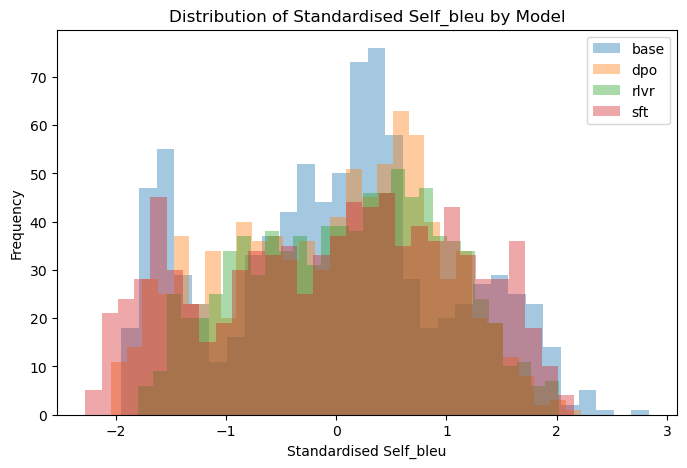

Plotting perplexity distribution for model: base, number of entries: 880, unique values: 880
Plotting perplexity distribution for model: dpo, number of entries: 880, unique values: 880
Plotting perplexity distribution for model: rlvr, number of entries: 880, unique values: 880
Plotting perplexity distribution for model: sft, number of entries: 880, unique values: 880


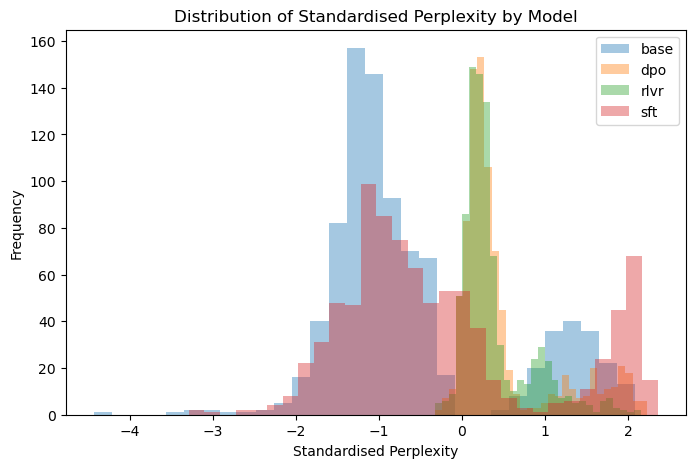

In [11]:
# Plot distribution of stansardised and transformed metrics
import matplotlib.pyplot as plt

for metric in regression_metrics:
    plt.figure(figsize=(8, 5))
    for model_name, group in linreg_df.groupby('model_key'):
        print(f"Plotting {metric} distribution for model: {model_name}, number of entries: {len(group)}, unique values: {group[metric].nunique()}")
        plt.hist(group[metric], bins=30, alpha=0.4, label=model_name)
    plt.xlabel(f'Standardised {metric.capitalize()}')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Standardised {metric.capitalize()} by Model')
    plt.legend()
    plt.show()